In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
plt.rcParams["figure.figsize"] = (10, 5)
FILE_PATH = os.path.join("data", "diabetes_012_health_indicators_BRFSS2015-.csv")

In [86]:
#LOADING DATA
def data_load(file):
    df = pd.read_csv(file)
    return df

In [87]:
df = data_load(FILE_PATH)

In [88]:
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [89]:
df.shape

(253680, 22)

In [90]:
#CLEANING DATA FOR VISUALIZATIONS
def data_cleaning(df):
    df.dropna(inplace=True)

    df.rename(columns={
        "Diabetes_012": "DiabetesStatus",
        "HeartDiseaseorAttack": "HeartDisease",
        "HvyAlcoholConsump": "HeavyAlcoholConsumption",
        "NoDocbcCost": "NoDoctorBecauseCost",
        "GenHlth": "GeneralHealth",
        "MentHlth": "MentalHealthLast30D",
        "PhysHlth": "PhysicalHealthLast30D",
        "DiffWalk": "WalkingDifficulty"
    }, inplace=True)

    df.replace({"DiabetesStatus" : {0.0: "No diabetes", 1.0: "Pre diabetes", 2.0: "Diabetes"}},inplace=True)

    df.replace({"HighBP" : {0.0: "No high BP", 1.0: "High BP"}},inplace=True)

    df.replace({"HighChol" : {0.0: "No high cholesterol", 1.0: "High cholesterol"}},inplace=True)

    df.replace({"CholCheck" : {0.0: "No cholesterol check in 5 years", 1.0: "Yes cholesterol check in 5 years"}},inplace=True)

    df.replace({"Smoker" : {0.0: "No", 1.0: "Yes"}},inplace=True)

    df.replace({"Stroke" : {0.0: "No stroke", 1.0: "Had a stroke"}},inplace=True)

    df.replace({"HeartDisease" : {0.0: "No heart disease", 1.0: "Yes heart disease"}},inplace=True)

    df.replace({"PhysActivity" : {0.0: "No PhysActivity", 1.0: "Yes PhysActivity"}},inplace=True)

    df.replace({"Fruits" : {0.0: "No at least 1 fruit a day", 1.0: "Yes at least 1 fruit a day"}},inplace=True)

    df.replace({"Veggies" : {0.0: "No at least 1 veggie a day", 1.0: "Yes at least 1 veggie a day"}},inplace=True)

    df.replace({"HeavyAlcoholConsumption" : {0.0: "No heavy drinking", 1.0: "Yes heavy drinking"}},inplace=True)

    df.replace({"AnyHealthcare" : {0.0: "No coverage", 1.0: "Has coverage"}},inplace=True)

    df.replace({"NoDoctorBecauseCost" : {0.0: "No cost barrier", 1.0: "Cost prevented doctor visit"}},inplace=True)

    df.replace({"GeneralHealth" : {1.0: "Excellent GH", 2.0: "Very Good GH", 3.0: "Good GH", 4.0: "Fair GH", 5.0: "Poor GH"}},inplace=True)

    df["MentalHealthLast30D"] = df["MentalHealthLast30D"].apply(categorize_mentalhealth)

    df["PhysicalHealthLast30D"] = df["PhysicalHealthLast30D"].astype(int)

    df["PhysicalHealthLast30D"] = df["PhysicalHealthLast30D"].apply(format_physicalhealth)

    df.replace({"WalkingDifficulty" : {0.0: "No difficulty walking", 1.0: "Yes have difficulty walking"}},inplace=True)

    df.replace({"Sex": {0.0: "Female", 1.0: "Male"}},inplace=True)

    education_map = {
        1: "No School",
        2: "Elementary",
        3: "Some High School",
        4: "High School Grad",
        5: "Some College",
        6: "College Grad"
    }
    df["Education"] = df["Education"].map(education_map)

    income_map = {
        1: "Less than $10k",
        2: "$10k–$14,999",
        3: "$15k–$19,999",
        4: "$20k–$24,999",
        5: "$25k–$34,999",
        6: "$35k–$49,999",
        7: "$50k–$74,999",
        8: "Equal to or more than $75k"
    }
    df["Income"] = df["Income"].map(income_map)

    age_map = {
        1: "18–24",
        2: "25–29",
        3: "30–34",
        4: "35–39",
        5: "40–44",
        6: "45–49",
        7: "50–54",
        8: "55–59",
        9: "60–64",
        10: "65–69",
        11: "70–74",
        12: "75–79",
        13: "80+"
    }
    df["Age"] = df["Age"].map(age_map)
    return df

In [91]:
#CATEGORZING MENTALHEALTH COLUMN
def categorize_mentalhealth(days):
    if days <= 5:
        return "Good, Less than 5 days"
    elif days <= 15:
        return "Moderate, less than 15"
    else:
        return "Poor, more than 15"

#FORMATING PHYSICALHEALTH COLUMN
def format_physicalhealth(days):
    return f"{days}" + " Days"

In [92]:
df = data_cleaning(df)

In [93]:
df.head()

,DiabetesStatus,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDisease,PhysActivity,Fruits,...,AnyHealthcare,NoDoctorBecauseCost,GeneralHealth,MentalHealthLast30D,PhysicalHealthLast30D,WalkingDifficulty,Sex,Age,Education,Income
0,No diabetes,High BP,High cholesterol,Yes cholesterol check in 5 years,40.0,Yes,No stroke,No heart disease,No PhysActivity,No at least 1 fruit a day,...,Has coverage,No cost barrier,Poor GH,"Poor, more than 15",15 Days,Yes have difficulty walking,Female,60–64,High School Grad,"$15k–$19,999"
1,No diabetes,No high BP,No high cholesterol,No cholesterol check in 5 years,25.0,Yes,No stroke,No heart disease,Yes PhysActivity,No at least 1 fruit a day,...,No coverage,Cost prevented doctor visit,Good GH,"Good, Less than 5 days",0 Days,No difficulty walking,Female,50–54,College Grad,Less than $10k
2,No diabetes,High BP,High cholesterol,Yes cholesterol check in 5 years,28.0,No,No stroke,No heart disease,No PhysActivity,Yes at least 1 fruit a day,...,Has coverage,Cost prevented doctor visit,Poor GH,"Poor, more than 15",30 Days,Yes have difficulty walking,Female,60–64,High School Grad,Equal to or more than $75k
3,No diabetes,High BP,No high cholesterol,Yes cholesterol check in 5 years,27.0,No,No stroke,No heart disease,Yes PhysActivity,Yes at least 1 fruit a day,...,Has coverage,No cost barrier,Very Good GH,"Good, Less than 5 days",0 Days,No difficulty walking,Female,70–74,Some High School,"$35k–$49,999"
4,No diabetes,High BP,High cholesterol,Yes cholesterol check in 5 years,24.0,No,No stroke,No heart disease,Yes PhysActivity,Yes at least 1 fruit a day,...,Has coverage,No cost barrier,Very Good GH,"Good, Less than 5 days",0 Days,No difficulty walking,Female,70–74,Some College,"$20k–$24,999"


In [94]:
#BAR GRAPH FOR THE DIABETES STATUS OF THE PEOPLE WHO TOOK THE SURVEY
def plot_diabetes_status(df):
    colors = ["seagreen", "darkred", "gold"]
    counts = df["DiabetesStatus"].value_counts()
    values = counts.values
    plt.bar(counts.index,counts.values,color=colors)
    plt.title('Diabetes Status Counts')
    for i, v in enumerate(values):
        plt.text(i, v+1000, str(v),ha="center", fontweight="bold")
    plt.xlabel('Diabetes Status')
    plt.ylabel('Count')
    plt.show()
    plt.close()  
    total = len(df)
    print(f"{total} People")
    print("In this survey")
    print(f"The number of people who doesnt have diabetes: {values[0]} and they are {round(values[0]/total*100,2)}%")
    print(f"The number of people who have diabetes: {values[1]} and they are {round(values[1]/total*100,2)}%")
    print(f"The number of people who have Pre diabetes: {values[2]} and they are {round(values[2]/total*100,2)}%")

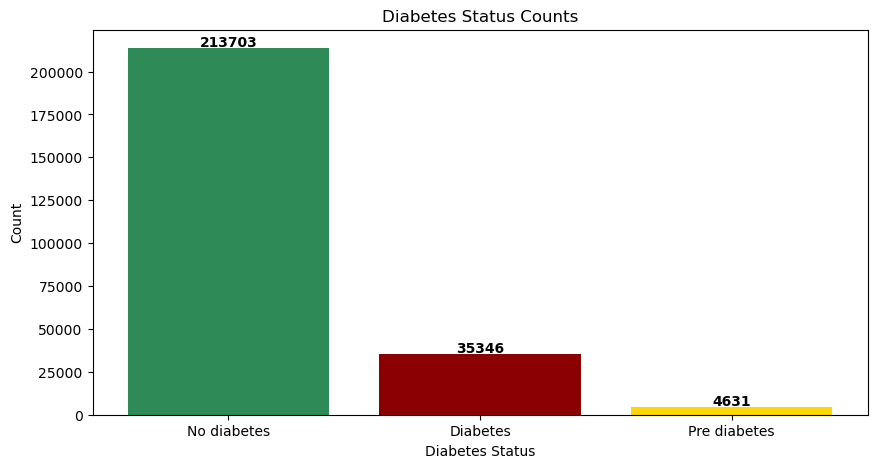

253680 People
In this survey
The number of people who doesnt have diabetes: 213703 and they are 84.24%
The number of people who have diabetes: 35346 and they are 13.93%
The number of people who have Pre diabetes: 4631 and they are 1.83%


In [95]:
plot_diabetes_status(df)

In [96]:
#BAR GRAPH FOR THE SMOKERS AND HEART DISEASES AND STROKES
def plot_smokers_health(df):
    smokers_count = df[df["Smoker"] == "Yes"]["HeartDisease"].value_counts()
    smokers_count2 = df[df["Smoker"] == "Yes"]["Stroke"].value_counts()
    x_axis = ["Heart disease","Stroke"]
    y_axis = [smokers_count.values[1],smokers_count2.values[1]]
    plt.bar(x_axis, y_axis)
    for i, v in enumerate(y_axis):
        plt.text(i, v + 100, str(v), ha="center", fontweight="bold")
    plt.title("Smokers and health diseases")
    plt.xlabel('Diseases')
    plt.ylabel('Count')
    plt.show()
    plt.close()  
    print(f"The amount of smokers that had a heart disease: {smokers_count.values[1]}")
    print(f"The amount of smokers that had a stroke: {smokers_count2.values[1]}")

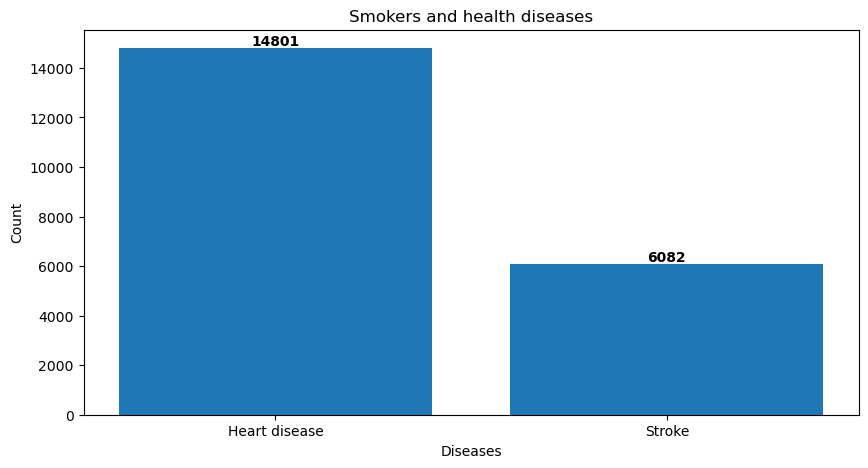

The amount of smokers that had a heart disease: 14801
The amount of smokers that had a stroke: 6082


In [97]:
plot_smokers_health(df)

In [98]:
#BAR GRAPH FOR THE DIABETIC SMOKERS WITH HEART DISEASES OR STROKES
def plot_diabetic_smokers(df):
    diabetic_smoker = df[(df["Smoker"] == "Yes") & (df["HeartDisease"] == "Yes heart disease")]["DiabetesStatus"].value_counts()
    diabetic_smoker2 = df[(df["Smoker"] == "Yes") & (df["Stroke"] == "Had a stroke")]["DiabetesStatus"].value_counts()
    x_axis = ["Diabetic Smokers Heart disease","Diabetic Smokers Stroke"]
    y_axis = [diabetic_smoker.values[1],diabetic_smoker2.values[1]]
    plt.bar(x_axis, y_axis, color=["darkred", "gold"])
    for i, v in enumerate(y_axis):
        plt.text(i, v+100, str(v),ha="center", fontweight="bold")
    plt.title("Diabetic Smokers diseases")
    plt.xlabel("Diseases")
    plt.ylabel("Count")
    plt.show()
    plt.close()  
    total_diabetic_smokers = len(df[(df["Smoker"]=="Yes") & (df["DiabetesStatus"]=="Diabetes")])
    print(f"The amount of diabetic smokers with heart diseases is {diabetic_smoker.iloc[1]} and they are {round(diabetic_smoker.iloc[1]/total_diabetic_smokers*100,2)}% of the total diabetic smokers")
    print(f"The amount of diabetic smokers that had a stroke {diabetic_smoker2.iloc[1]} and they are {round(diabetic_smoker2.iloc[1]/total_diabetic_smokers*100,2)}% of the total diabetic smokers")

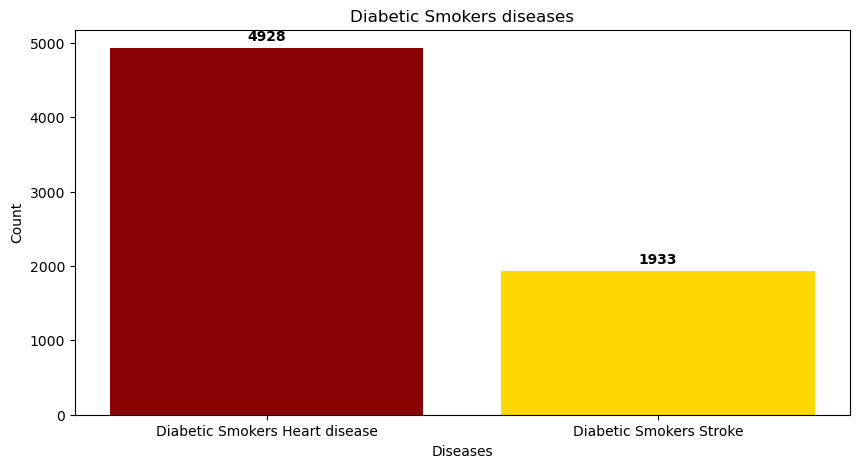

The amount of diabetic smokers with heart diseases is 4928 and they are 26.9% of the total diabetic smokers
The amount of diabetic smokers that had a stroke 1933 and they are 10.55% of the total diabetic smokers


In [99]:
plot_diabetic_smokers(df)

In [100]:
#LINECHART FOR DIABETES AND AGE RELATION
def plot_age_diabetes(df):
    age_counts = df[df["DiabetesStatus"] == "Diabetes"]["Age"].value_counts()
    age_counts = age_counts.sort_index()
    plt.plot(age_counts.index, age_counts.values,marker="o",color="gold")
    plt.xlabel("Age")
    plt.ylabel("Counts of people with diabetes")
    plt.title("Correlation between age and diabetes")
    plt.grid(True)
    plt.show()
    plt.close()  
    print("People aged 50 and older have a higher incidence of diabetes, suggesting age is an important risk factor for diabetes.")

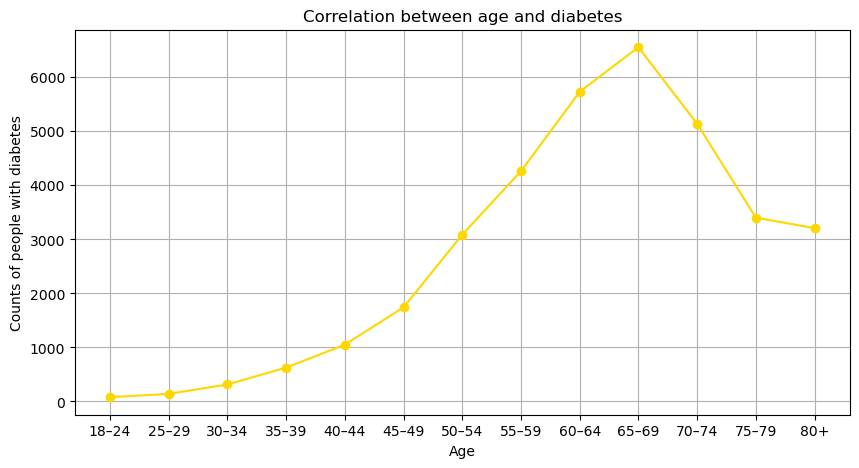

People aged 50 and older have a higher incidence of diabetes, suggesting age is an important risk factor for diabetes.


In [101]:
plot_age_diabetes(df)

In [102]:
#BOXPLOT TO COMPARE THE BMI DISTRIBUTIONS ACROSS DIABETES STASUSES
def plot_bmi_boxplot(df):
    plt.figure(figsize=(7, 9))
    sns.boxplot(x="DiabetesStatus", y="BMI", hue="DiabetesStatus", data=df, palette="Set2", showfliers=False, legend=False)
    plt.ylim(15, 50)
    plt.title("BMI Distribution by Diabetes Status")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()  
    print("There is a strong positive correlation between higher BMI and the likelihood of having diabetes. Individuals diagnosed with diabetes tend to have significantly higher BMI values compared to non-diabetic and pre-diabetic individuals.")
    print(df.groupby("DiabetesStatus")["BMI"].describe())

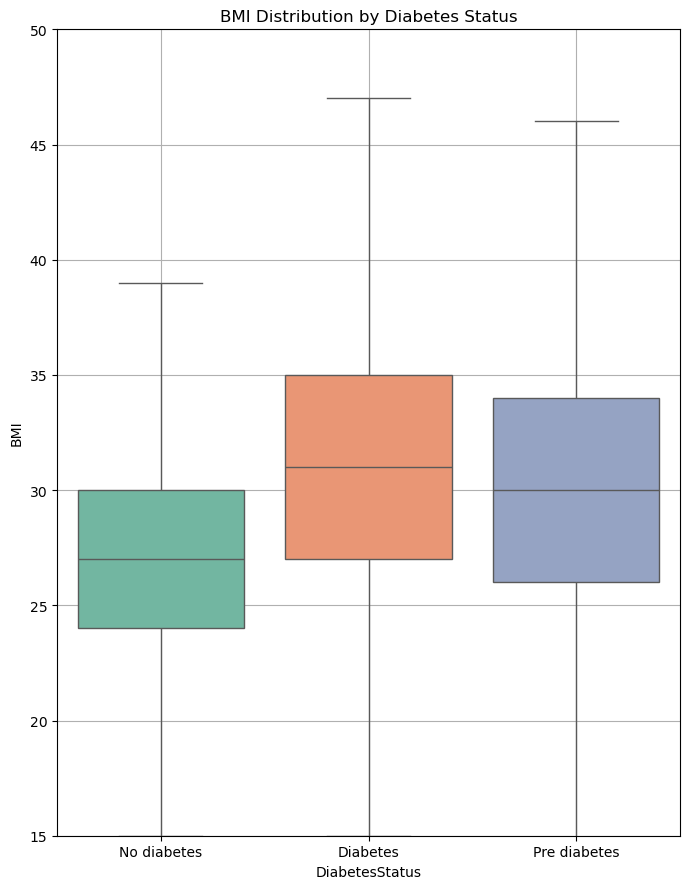

There is a strong positive correlation between higher BMI and the likelihood of having diabetes. Individuals diagnosed with diabetes tend to have significantly higher BMI values compared to non-diabetic and pre-diabetic individuals.
                   count       mean       std   min   25%   50%   75%   max
DiabetesStatus                                                             
Diabetes         35346.0  31.944011  7.363401  13.0  27.0  31.0  35.0  98.0
No diabetes     213703.0  27.742521  6.260993  12.0  24.0  27.0  30.0  98.0
Pre diabetes      4631.0  30.724466  6.964898  13.0  26.0  30.0  34.0  96.0


In [103]:
plot_bmi_boxplot(df)

In [104]:
def plot_correlation_heatmap(filepath):
    df2 = pd.read_csv(filepath)
    plt.figure(figsize=(16, 10))
    sns.heatmap(df2.select_dtypes(include=["number"]).corr(), annot=True, fmt=".3f")
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=8)
    plt.show()
    corr_matrix = df2.corr(numeric_only=True)
    corr_melted = corr_matrix.reset_index().melt(id_vars='index')
    corr_melted.columns = ['Var1', 'Var2', 'Correlation']
    # Saving it as a Tableau-friendly CSV
    corr_melted.to_csv('correlation_matrix_long.csv', index=False)

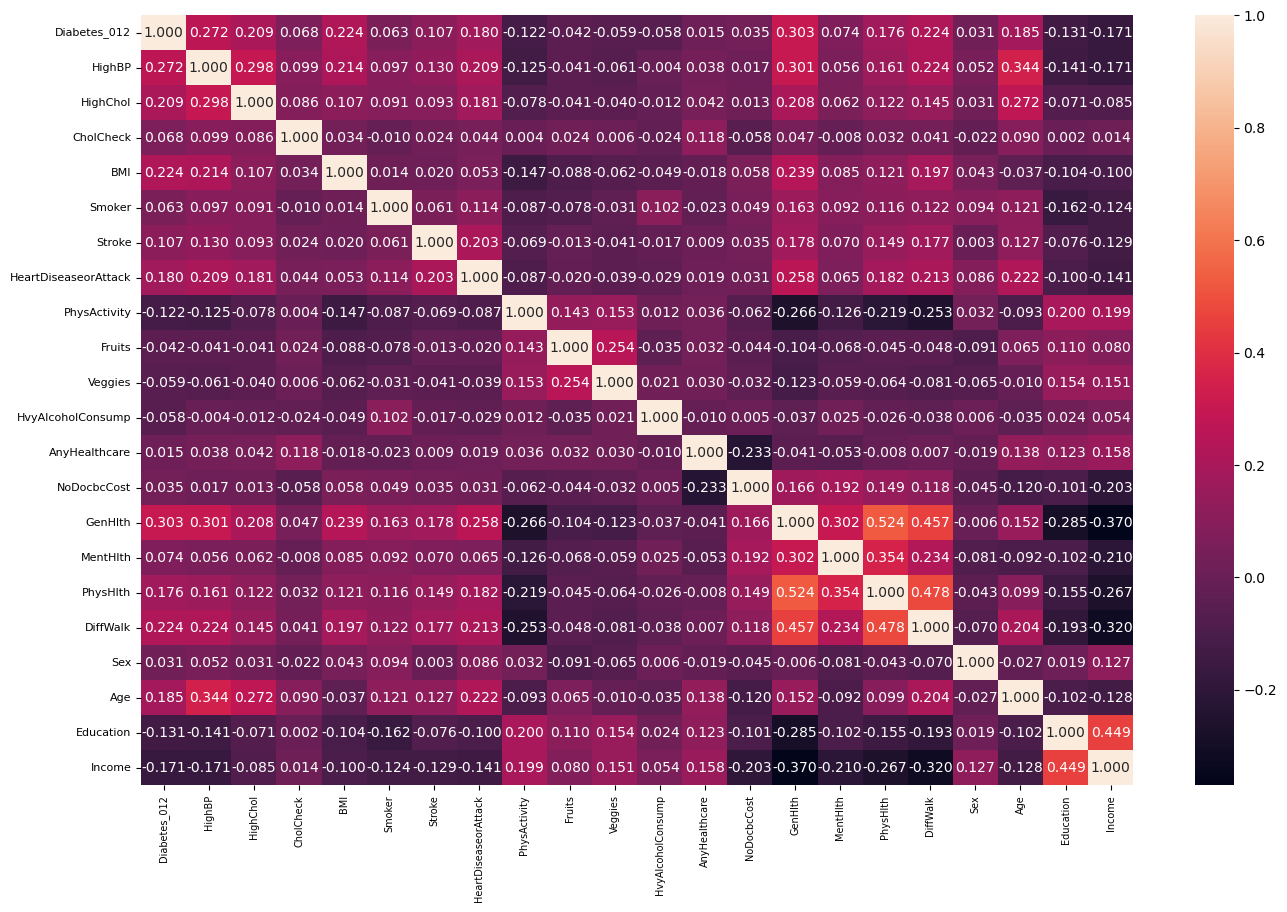

In [105]:
plot_correlation_heatmap(FILE_PATH)

In [106]:
df.to_csv("cleaned_diabetes_data.csv", index=False)